# makeshift — quick start

This notebook covers the core workflow:
- Fetching an NMR-STAR file from BMRB
- Parsing it into a tidy chemical shift dataframe
- Handling multi-entity entries
- Calculating and visualising the Chemical Shift Index (CSI)

In [1]:
import makeshift as ms
import seaborn as sns
import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


## 1. Fetch and parse a BMRB entry

`fetch_nmrstar_file` downloads the NMR-STAR v3 file for a given BMRB ID and saves it locally.
`parse_nmr_star` reads it into a nested dict keyed by saveframe category.

In [2]:
# Unphosphorylated NtrCr — Volkman & Kern 2001
ms.fetch_nmrstar_file(4527)  # saves bmr4527_3.str to the current directory
entry = ms.parse_nmr_star('bmr4527_3.str')

## 2. Extract chemical shifts

`get_chem_shifts` returns a tidy dataframe with one row per observed chemical shift.

Key columns:
| Column | Description |
|---|---|
| `Seq_ID` | Residue sequence number (1-indexed) |
| `Comp_ID` | Three-letter amino acid code |
| `Atom_ID` | Atom name (CA, CB, N, H, HA, C, ...) |
| `Atom_type` | Element (C, N, H) |
| `Val` | Observed chemical shift (ppm) |
| `cs_saveframe_id` | Which saveframe the shift came from (relevant for multi-saveframe entries) |

In [3]:
cs = ms.get_chem_shifts(entry)
cs

,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,name,cs_saveframe_id
0,1,2,.,GLN,CA,C,55.70,.,chemical_shift_set_1
1,1,2,.,GLN,HA,H,4.52,.,chemical_shift_set_1
2,1,2,.,GLN,CB,C,30.00,.,chemical_shift_set_1
3,1,2,.,GLN,HB2,H,2.12,.,chemical_shift_set_1
4,1,2,.,GLN,HB3,H,2.03,.,chemical_shift_set_1
...,...,...,...,...,...,...,...,...,...
1339,1,124,.,GLU,HB2,H,2.08,.,chemical_shift_set_1
1340,1,124,.,GLU,HB3,H,1.94,.,chemical_shift_set_1
1341,1,124,.,GLU,CG,C,36.80,.,chemical_shift_set_1
1342,1,124,.,GLU,HG2,H,2.28,.,chemical_shift_set_1


## 3. Simulate an HSQC

Pivot to one row per residue with N and H columns, then plot.

Text(0.5, 1.0, 'Simulated HSQC — NtrCr (4527)')

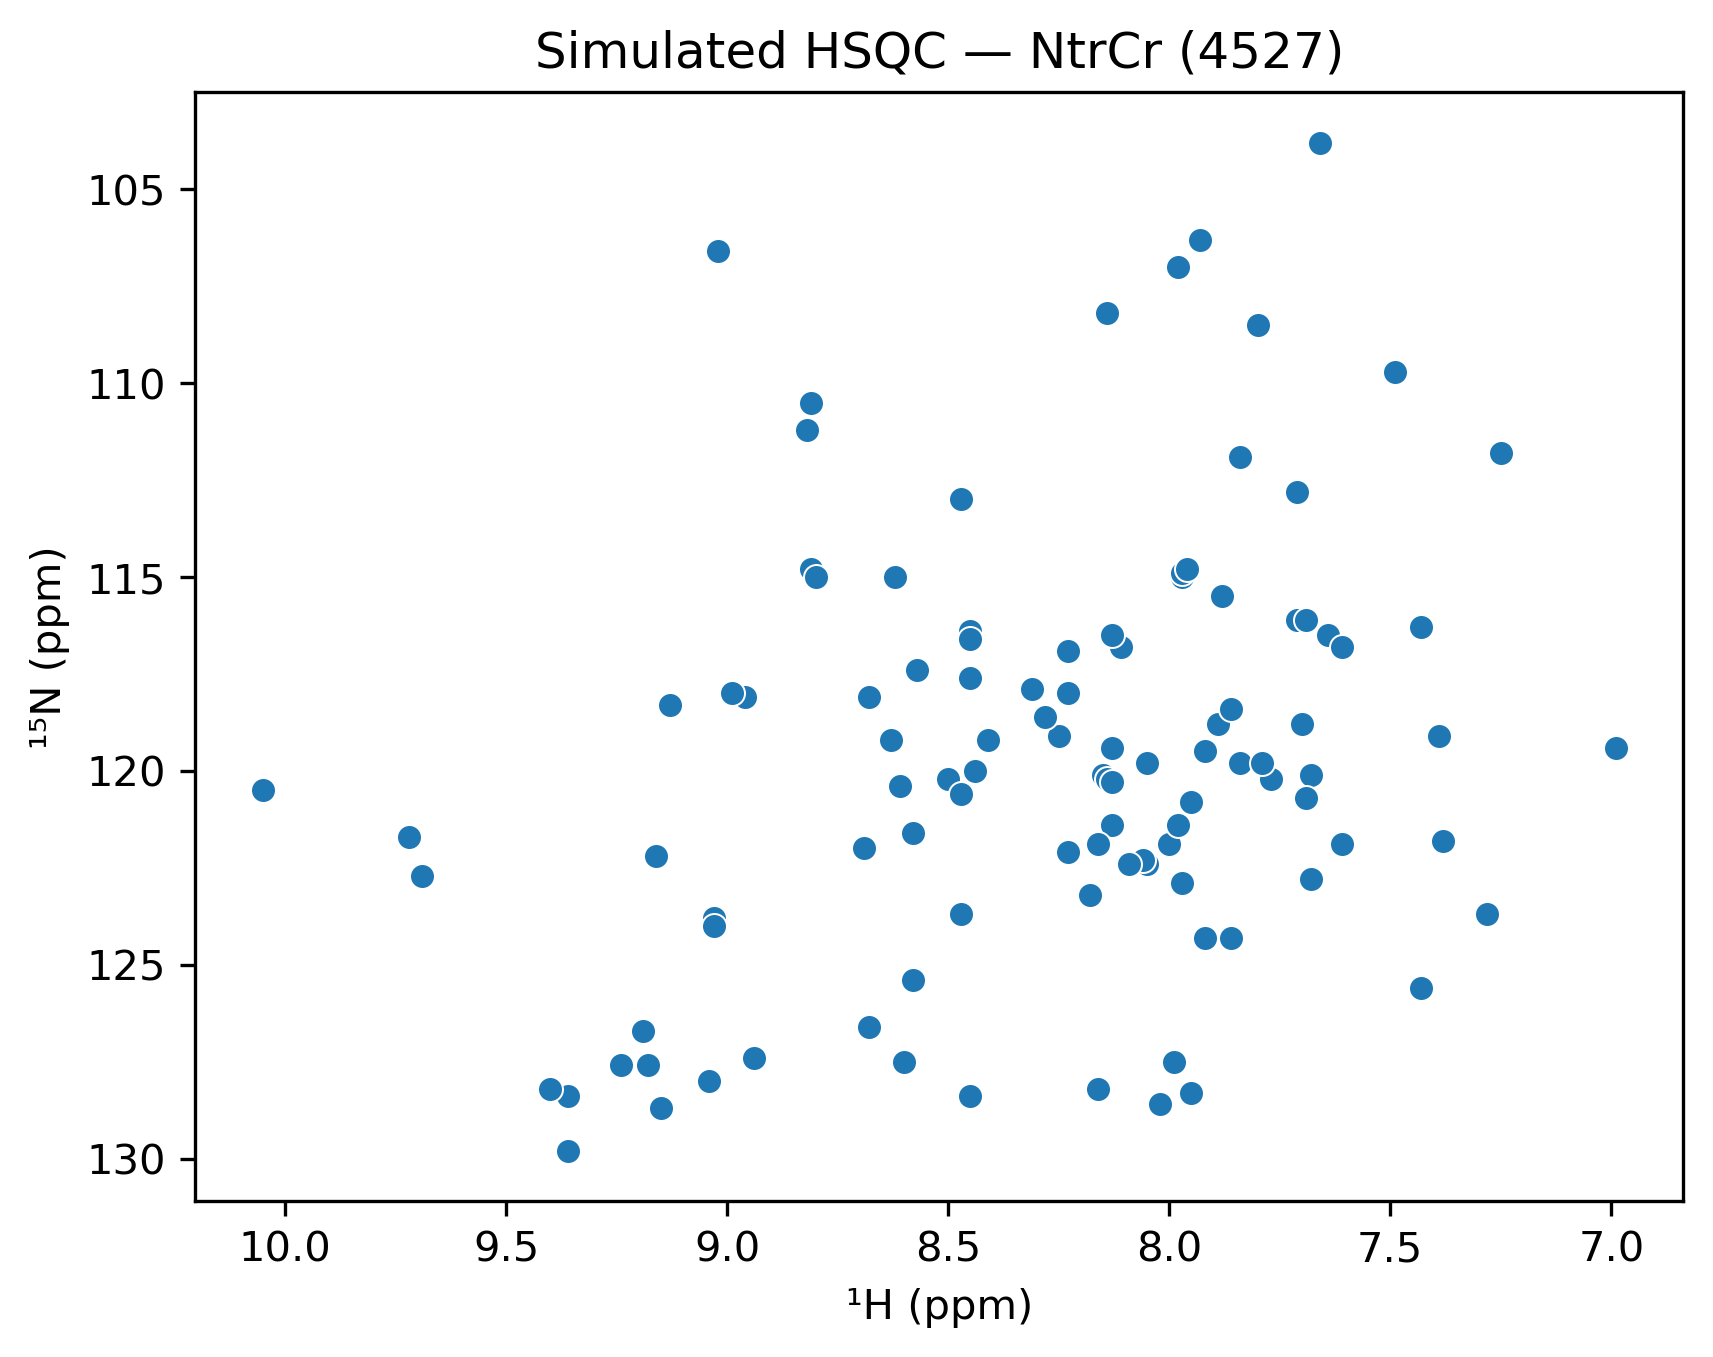

In [4]:
pivoted = (
    cs[cs['Atom_ID'].isin(['N', 'H'])]
    .pivot_table(
        index=['Entity_ID', 'Seq_ID', 'Comp_ID'],
        columns='Atom_type',
        values='Val',
    )
    .reset_index()
)
pivoted.columns.name = None

sns.scatterplot(x='H', y='N', data=pivoted)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('¹H (ppm)')
plt.ylabel('¹⁵N (ppm)')
plt.title('Simulated HSQC — NtrCr (4527)')

## 4. Multi-entity entries

Some BMRB entries contain multiple entities (e.g. a protein + DNA + ligand).
`get_sequences` lists them so you can filter to the one you want.

In [5]:
# hERR2 zinc finger bound to DNA — four entities: two DNA strands, protein, Zn
ms.fetch_nmrstar_file(5363)
entry = ms.parse_nmr_star('bmr5363_3.str')

entities = ms.get_sequences(entry)
entities

,entity,ID,Polymer_type,Polymer_seq_one_letter_code
0,hERR2,1,polypeptide(L),AIPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPAT...
1,DNA_strand1,2,polydeoxyribonucleotide,GCTCAAGGTCACG
2,DNA_strand2,3,polydeoxyribonucleotide,CGTGACCTTGAGC
3,ZN,4,.,.


In [6]:
cs = ms.get_chem_shifts(entry)

# Filter to polypeptide entity only
protein_ids = list(entities.loc[entities['Polymer_type'] == 'polypeptide(L)', 'ID'])
pcs = cs.loc[cs.Entity_ID.isin(protein_ids)]
pcs

,Entity_ID,Seq_ID,Auth_seq_ID,Comp_ID,Atom_ID,Atom_type,Val,name,cs_saveframe_id
0,1,1,97,ALA,CA,C,49.85,.,chemical_shifts_1
1,1,1,97,ALA,HA,H,4.11,.,chemical_shifts_1
2,1,1,97,ALA,CB,C,20.08,.,chemical_shifts_1
3,1,1,97,ALA,HB1,H,1.48,.,chemical_shifts_1
4,1,1,97,ALA,HB2,H,1.48,.,chemical_shifts_1
...,...,...,...,...,...,...,...,...,...
1085,1,97,193,ASN,HB2,H,2.68,.,chemical_shifts_1
1086,1,97,193,ASN,HB3,H,2.82,.,chemical_shifts_1
1087,1,97,193,ASN,ND2,N,112.85,.,chemical_shifts_1
1088,1,97,193,ASN,HD21,H,6.84,.,chemical_shifts_1


## 5. Chemical Shift Index (CSI)

Pass `calc_CSI=True` to compute two additional columns:

| Column | Description |
|---|---|
| `csi_raw` | (CA − CB) secondary shift (observed − random coil). Positive = helix tendency, negative = strand tendency. GLY falls back to CA-only secondary shift since it has no CB. |
| `csi` | Discretised index: +1 (helix), −1 (strand), 0 (coil/ambiguous) |

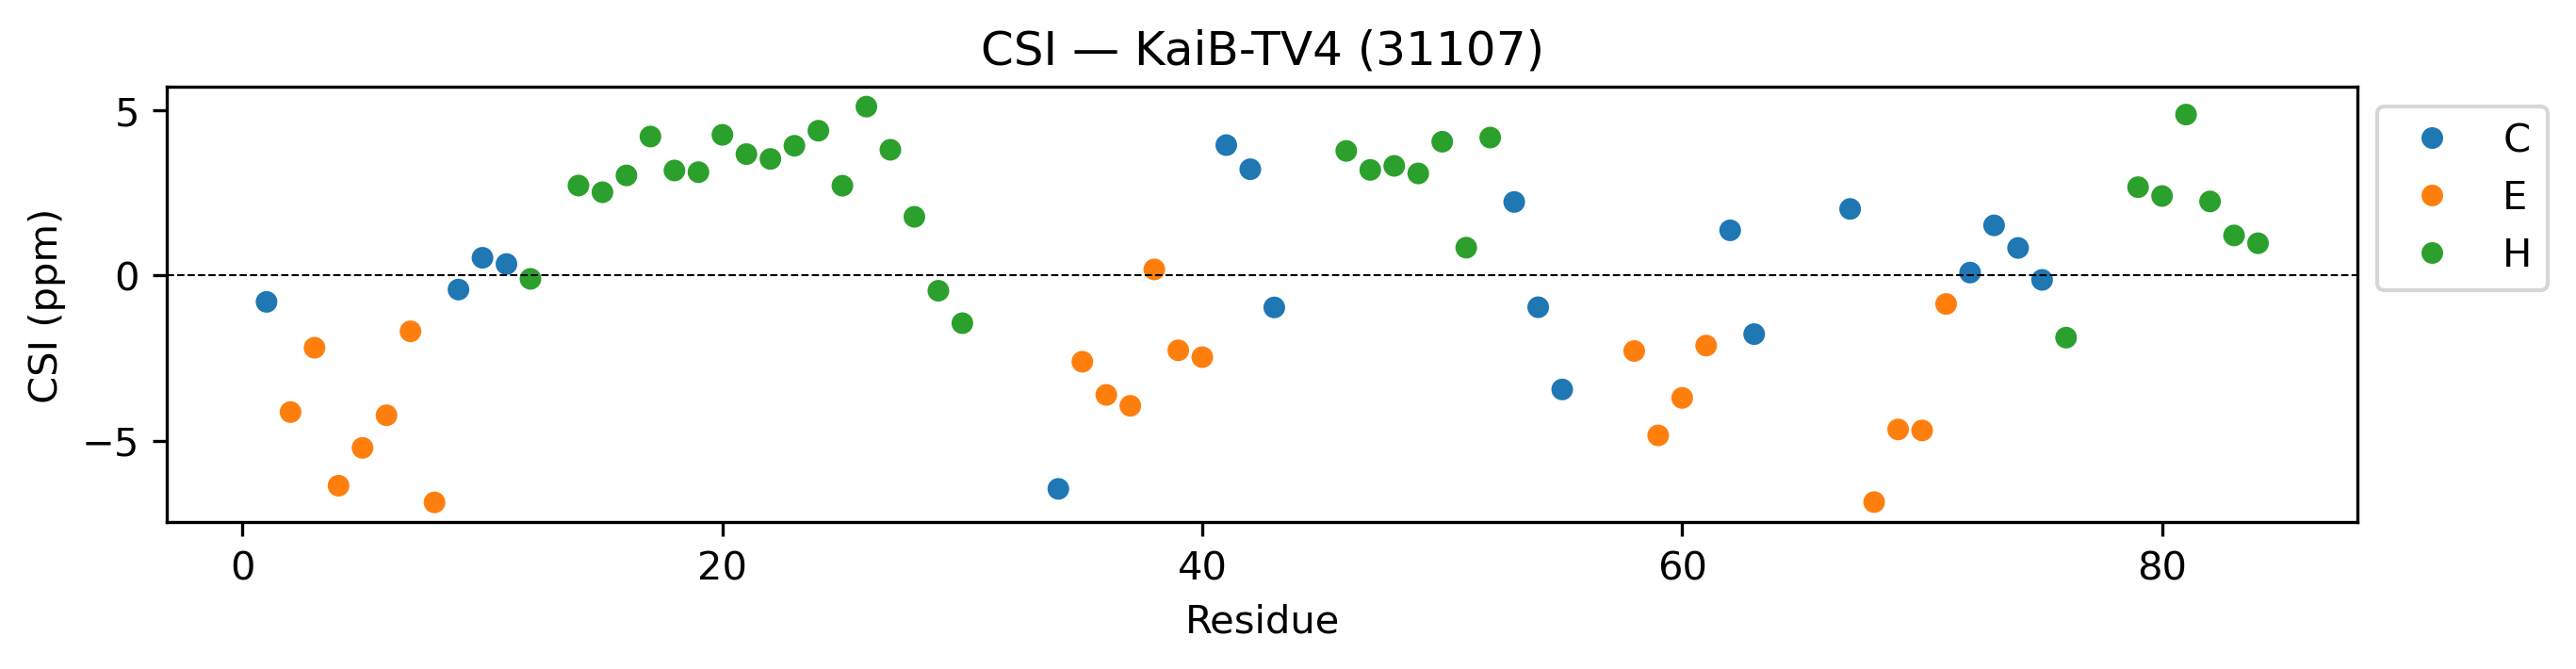

In [7]:
# KaiB-TV4 — a well-structured protein with known secondary structure
ms.fetch_nmrstar_file(31107)
entry = ms.parse_nmr_star('bmr31107_3.str')
cs = ms.get_chem_shifts(entry, calc_CSI=True)

# Known sequence and DSSP secondary structure assignment
seq = 'MYVFRLYVRGETHAAEVALKNLHDLLSSALKVPYTLKVVDVTKQPDLAEKDQVQATPTLVRVYPQPVRRLVGQLDHRYRLQHLLSP'
dss = 'CEEEEEEECCCHHHHHHHHHHHHHHHHHHHCCCCEEEEEECCCHHHHHHHHHCCCCCEEEECCCCCCEEEECCCCHHHHHHHHHHC'

tmp = cs.loc[cs.Atom_type == 'N'].copy()
tmp['dssp'] = tmp.apply(lambda row: dss[row['Seq_ID'] - 1], axis=1)

plt.figure(figsize=(10, 2))
sns.scatterplot(x='Seq_ID', y='csi_raw', hue='dssp', data=tmp)
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.xlabel('Residue')
plt.ylabel('CSI (ppm)')
plt.title('CSI — KaiB-TV4 (31107)')
plt.legend(bbox_to_anchor=(1, 1))

Text(0.5, 1.0, 'CSI — IDP (27401)')

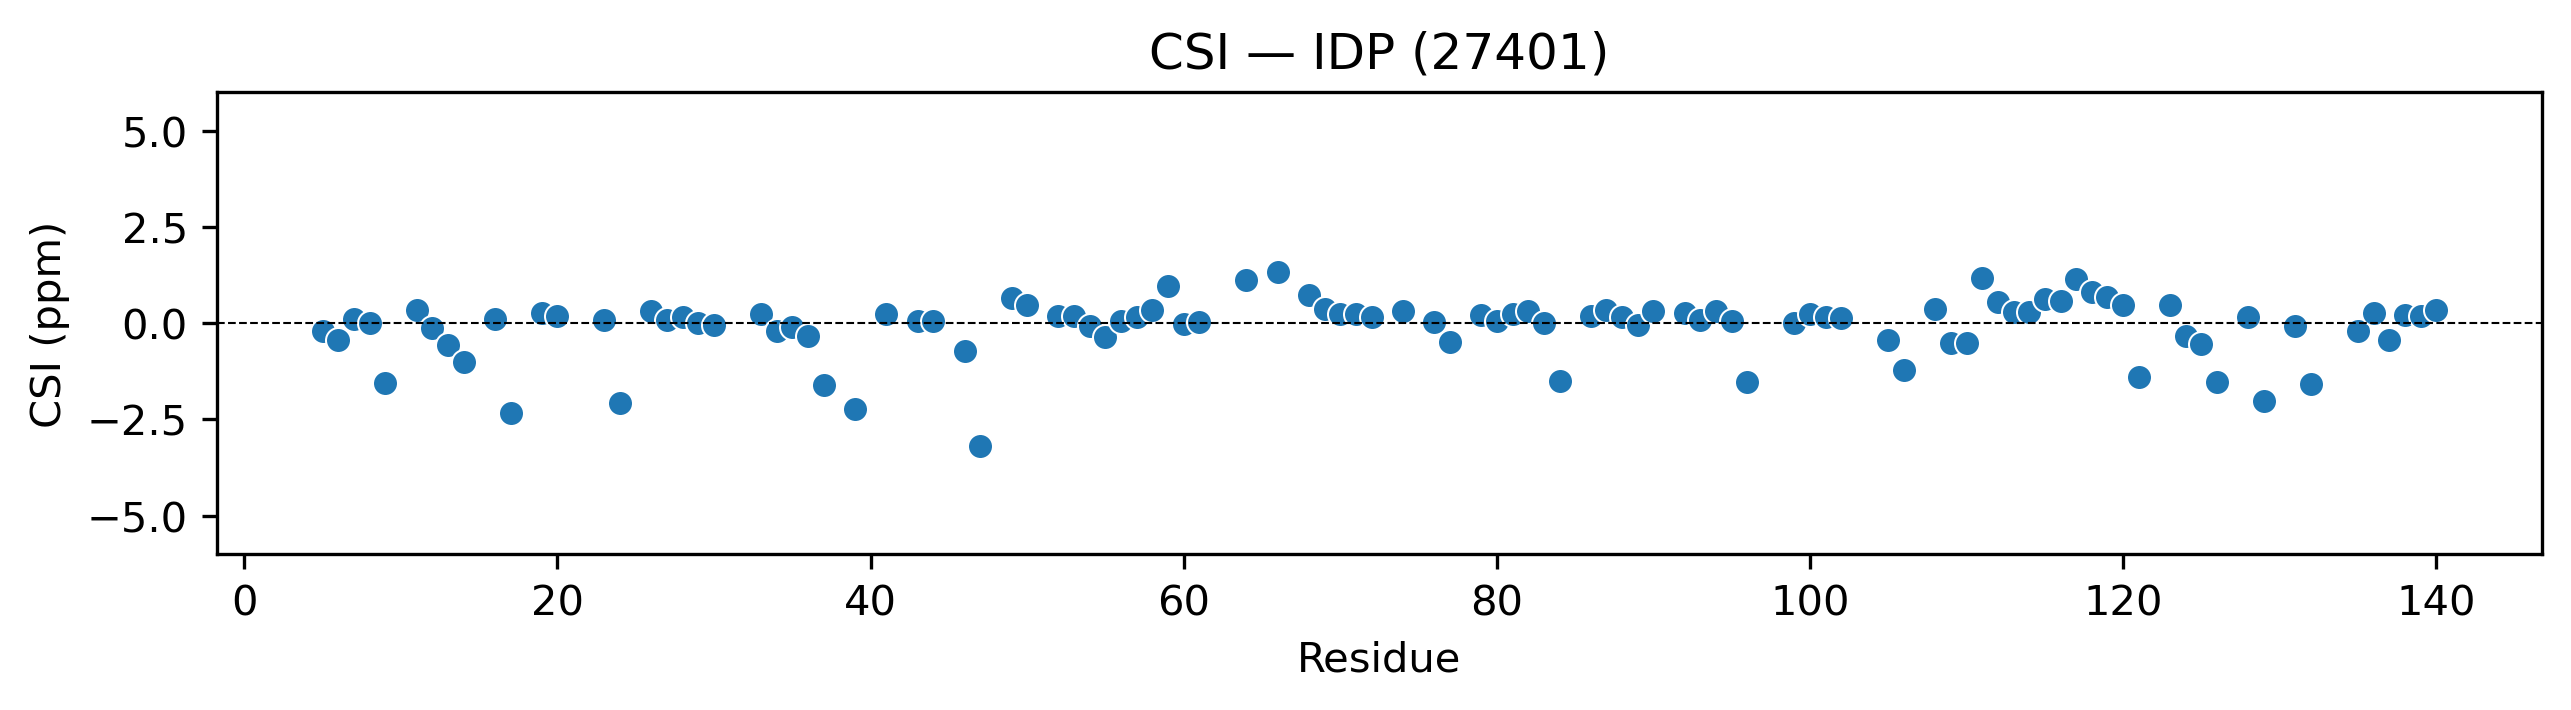

In [8]:
# Intrinsically disordered protein — CSI fluctuates around zero with no sustained trend
ms.fetch_nmrstar_file(27401)
entry = ms.parse_nmr_star('bmr27401_3.str')
cs = ms.get_chem_shifts(entry, calc_CSI=True)

tmp = cs.loc[cs.Atom_type == 'N']

plt.figure(figsize=(10, 2))
sns.scatterplot(x='Seq_ID', y='csi_raw', data=tmp)
plt.axhline(0, color='k', linewidth=0.5, linestyle='--')
plt.ylim([-6, 6])
plt.xlabel('Residue')
plt.ylabel('CSI (ppm)')
plt.title('CSI — IDP (27401)')